# CausalLM Test Metrics Overview

该笔记本会整理 `results/causalLM` 目录下每个任务、算法与随机种子的最优 test metric，并计算算法在各数据集上的中位数表现。


In [2]:
from pathlib import Path
import json
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-muted')
BASE_DIR = Path('results/facebook/opt-6.7b')
ALGORITHMS = [ 'SAES_id']
SEEDS = [0, 1, 42, 43, 100]
coef = 0.01



In [3]:
def load_best_test_metrics(base_dir: Path = BASE_DIR,
                           algorithms: List[str] = ALGORITHMS,
                           seeds: List[int] = SEEDS,
                           coef: float = coef) -> Tuple[pd.DataFrame, List[Tuple[str, str, int, str]]]:
    rows = []
    missing = []
    task_dirs = sorted([p for p in base_dir.iterdir() if p.is_dir()])

    for task_dir in task_dirs:
        task = task_dir.name
        for alg in algorithms:
            for seed in seeds:
                seed_dir = task_dir / alg 
                if not seed_dir.exists():
                    missing.append((task, alg, seed, 'dir_missing'))
                    continue
                # 在此处加入 coef 前缀进行文件匹配
                json_files = sorted(seed_dir.glob(f"coef{coef}*.json"))
                if not json_files:
                    missing.append((task, alg, seed, 'no_json'))
                    continue
                with json_files[-1].open() as f:
                    data = json.load(f)
                best_metric = max(step['metric'] for step in data['test'])
                rows.append({
                    'task': task,
                    'algorithm': alg,
                    'seed': seed,
                    'best_metric': best_metric,
                })

    return pd.DataFrame(rows), missing


df_best, missing_info = load_best_test_metrics()
df_best.head()


,task,algorithm,seed,best_metric
0,cola,SAES_id,0,0.024041
1,cola,SAES_id,1,0.024041
2,cola,SAES_id,42,0.024041
3,cola,SAES_id,43,0.024041
4,cola,SAES_id,100,0.024041


In [4]:
if missing_info:
    print('Missing results:')
    for record in missing_info:
        print(record)
else:
    print('All requested runs found.')

mean_table = (df_best
                .groupby(['task', 'algorithm'])['best_metric']
                .mean()
                .unstack('algorithm')
                .sort_index()) * 100
mean_table


All requested runs found.


algorithm,SAES_id
task,
cola,2.404116
mnli,37.300000
mrpc,81.049563
qnli,54.100000
qqp,54.469854
rte,57.400722
sst2,88.761468


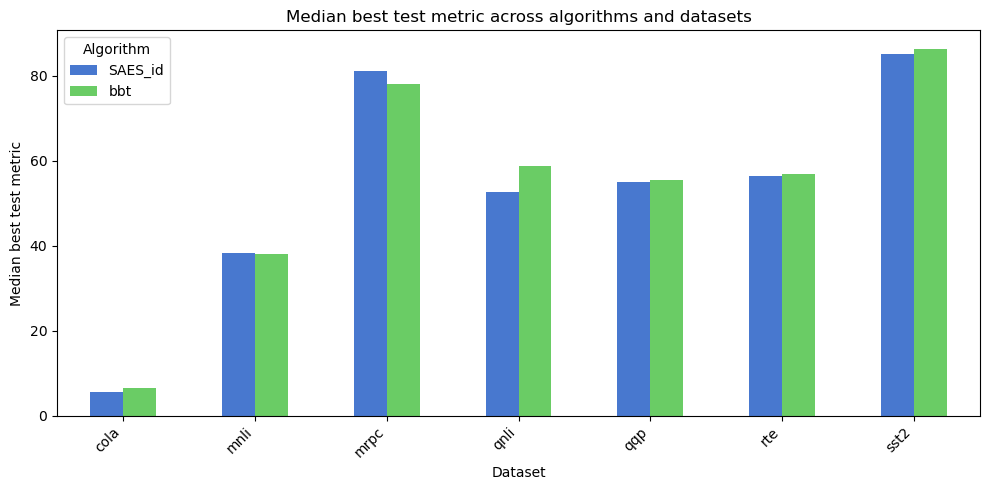

In [7]:
ax = mean_table.plot(kind='bar', figsize=(10, 5))
ax.set_ylabel('Median best test metric')
ax.set_xlabel('Dataset')
ax.set_title('Median best test metric across algorithms and datasets')
ax.legend(title='Algorithm')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


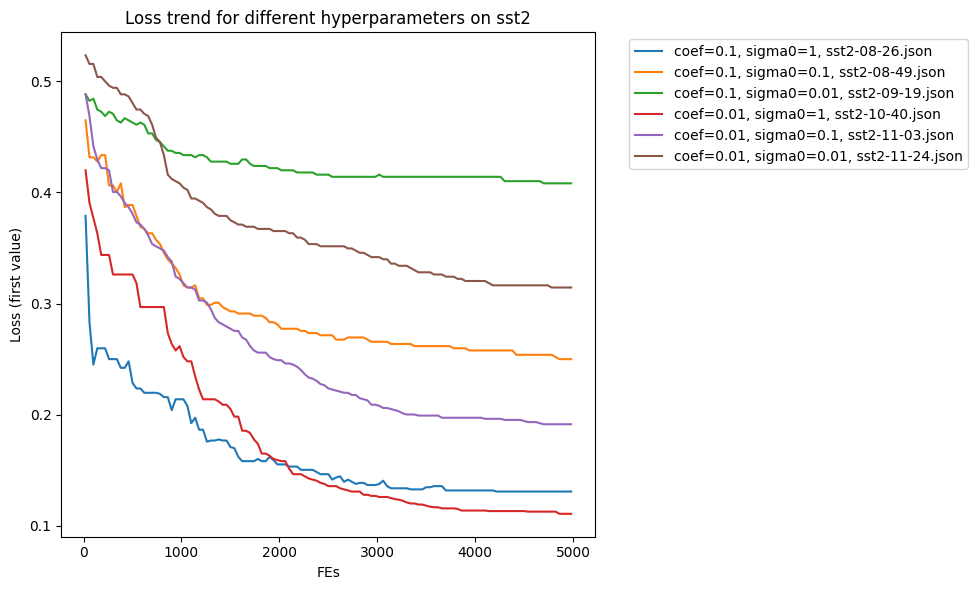

In [16]:
import os
import json
import matplotlib.pyplot as plt

base_folder = "results/temp1/facebook/opt-6.7b/sst2/SAES_id_e/"
coef_list = [ 0.1, 0.01]
sigma_list = [1, 1e-1, 1e-2 ]

plt.figure(figsize=(10, 6))

for coef in coef_list:
    for sigma0 in sigma_list:
        folder_name = f"coef-{coef}_sigma0-{sigma0}"
        folder_path = os.path.join(base_folder, folder_name)
        if not os.path.isdir(folder_path):
            continue
        # Assume there may be multiple json files
        for file in os.listdir(folder_path):
            if file.endswith('.json'):
                file_path = os.path.join(folder_path, file)
                with open(file_path, 'r') as f:
                    data = json.load(f)
                train_data = data.get('train', [])
                if not train_data:
                    continue
                FEs = [step.get('FEs', idx) for idx, step in enumerate(train_data)]
                losses = [step.get('loss', [None])[0] for step in train_data]
                label = f"coef={coef}, sigma0={sigma0}, {file}"
                plt.plot(FEs, losses, label=label)

plt.xlabel('FEs')
plt.ylabel('Loss (first value)')
plt.title('Loss trend for different hyperparameters on sst2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
figures_dir = "figures"
os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, "loss_trend_sst2.png"))
plt.show()

